<a href="https://colab.research.google.com/github/mukhorochok/HCL-Hackathon/blob/main/hybrid.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
train_df=pd.read_csv('train.csv')
train_df.describe()
train_df.info()
train_df.shape

/tmp/ipykernel_366/1584024045.py:1: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  train_df=pd.read_csv('train.csv')


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1017209 entries, 0 to 1017208
Data columns (total 9 columns):
 #   Column         Non-Null Count    Dtype 
---  ------         --------------    ----- 
 0   Store          1017209 non-null  int64 
 1   DayOfWeek      1017209 non-null  int64 
 2   Date           1017209 non-null  object
 3   Sales          1017209 non-null  int64 
 4   Customers      1017209 non-null  int64 
 5   Open           1017209 non-null  int64 
 6   Promo          1017209 non-null  int64 
 7   StateHoliday   1017209 non-null  object
 8   SchoolHoliday  1017209 non-null  int64 
dtypes: int64(7), object(2)
memory usage: 69.8+ MB


(1017209, 9)

In [ ]:
#Checking for missing data
train_df.isna().sum()

,0
Store,0
DayOfWeek,0
Date,0
Sales,0
Customers,0
Open,0
Promo,0
StateHoliday,0
SchoolHoliday,0


In [ ]:
train_df.head(5)
type(train_df["Date"])

pandas.core.series.Series

In [ ]:
store_df=pd.read_csv('store.csv')
store_df.info()
store_df.head(5)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1115 entries, 0 to 1114
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Store                      1115 non-null   int64  
 1   StoreType                  1115 non-null   object 
 2   Assortment                 1115 non-null   object 
 3   CompetitionDistance        1112 non-null   float64
 4   CompetitionOpenSinceMonth  761 non-null    float64
 5   CompetitionOpenSinceYear   761 non-null    float64
 6   Promo2                     1115 non-null   int64  
 7   Promo2SinceWeek            571 non-null    float64
 8   Promo2SinceYear            571 non-null    float64
 9   PromoInterval              571 non-null    object 
dtypes: float64(5), int64(2), object(3)
memory usage: 87.2+ KB


,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN


Peform EDA on the Datasets
 train.csv and store.csv

In [ ]:
merged_df=pd.merge(train_df,store_df,on='Store',how='left')
merged_df.head(5)

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,5,2015-07-31,5263,555,1,1,0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,5,2015-07-31,6064,625,1,1,0,1,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,5,2015-07-31,8314,821,1,1,0,1,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,5,2015-07-31,13995,1498,1,1,0,1,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,5,2015-07-31,4822,559,1,1,0,1,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN


In [ ]:
#Modify the data types of the columns
merged_df['Date']=pd.to_datetime(merged_df['Date'])
merged_df['Year'] = merged_df['Date'].dt.year
merged_df['Month'] = merged_df['Date'].dt.month
merged_df['Day'] = merged_df['Date'].dt.day
merged_df['WeekOfYear'] = merged_df['Date'].dt.isocalendar().week
day_map = {
    1:"Monday",
    2:"Tuesday",
    3:"Wednesday",
    4:"Thursday",
    5:"Friday",
    6:"Saturday",
    7:"Sunday"
}

merged_df["DayName"] = merged_df["DayOfWeek"].map(day_map)
merged_df.info()
merged_df.head(5)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1017209 entries, 0 to 1017208
Data columns (total 23 columns):
 #   Column                     Non-Null Count    Dtype         
---  ------                     --------------    -----         
 0   Store                      1017209 non-null  int64         
 1   DayOfWeek                  1017209 non-null  int64         
 2   Date                       1017209 non-null  datetime64[ns]
 3   Sales                      1017209 non-null  int64         
 4   Customers                  1017209 non-null  int64         
 5   Open                       1017209 non-null  int64         
 6   Promo                      1017209 non-null  int64         
 7   StateHoliday               1017209 non-null  object        
 8   SchoolHoliday              1017209 non-null  int64         
 9   StoreType                  1017209 non-null  object        
 10  Assortment                 1017209 non-null  object        
 11  CompetitionDistance        1014567 no

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,...,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval,Year,Month,Day,WeekOfYear,DayName
0,1,5,2015-07-31,5263,555,1,1,0,1,c,...,2008.0,0,NaN,NaN,NaN,2015,7,31,31,Friday
1,2,5,2015-07-31,6064,625,1,1,0,1,a,...,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct",2015,7,31,31,Friday
2,3,5,2015-07-31,8314,821,1,1,0,1,a,...,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct",2015,7,31,31,Friday
3,4,5,2015-07-31,13995,1498,1,1,0,1,c,...,2009.0,0,NaN,NaN,NaN,2015,7,31,31,Friday
4,5,5,2015-07-31,4822,559,1,1,0,1,a,...,2015.0,0,NaN,NaN,NaN,2015,7,31,31,Friday


Visualising Sales Distribution for Stores

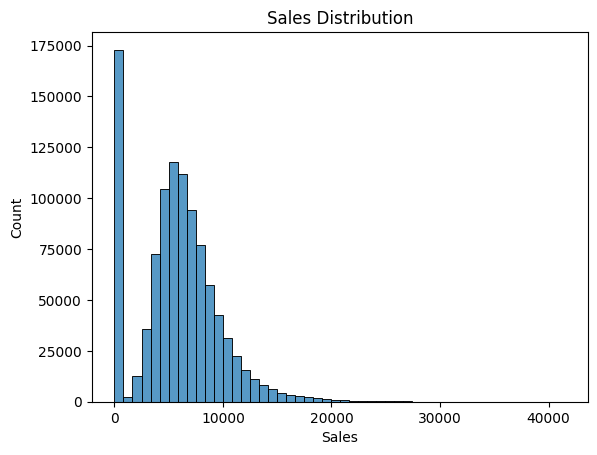

In [ ]:
sns.histplot(merged_df['Sales'], bins=50)
plt.title("Sales Distribution")
plt.show()

We can see the right-skewdness of the distribution

Handling missing values using the median imputation

In [ ]:
merged_df['CompetitionDistance'].fillna(merged_df['CompetitionDistance'].median(), inplace=True)
#IF missing competitor data
merged_df['CompetitionOpenSinceMonth'].fillna(0, inplace=True)
merged_df['CompetitionOpenSinceYear'].fillna(0, inplace=True)
#If missing Promo details
merged_df['Promo2SinceWeek'].fillna(0, inplace=True)
merged_df['Promo2SinceYear'].fillna(0, inplace=True)
#Handling missing values in categorical columns
merged_df['PromoInterval'].fillna("None", inplace=True)




/tmp/ipykernel_366/4262586037.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  merged_df['CompetitionDistance'].fillna(merged_df['CompetitionDistance'].median(), inplace=True)
/tmp/ipykernel_366/4262586037.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doi

Remove Closed Stores to prevent Bias

In [ ]:
merged_df = merged_df[merged_df["Open"] == 1]

Convert Categorical Variables

In [ ]:
categorical_cols = ["StoreType","Assortment","StateHoliday"]

for col in categorical_cols:
    merged_df[col] = merged_df[col].astype("category")

Feature Engineering

In [ ]:
merged_df["IsWeekend"] = merged_df["DayOfWeek"].isin([6,7]).astype(int)

Trend Analysis

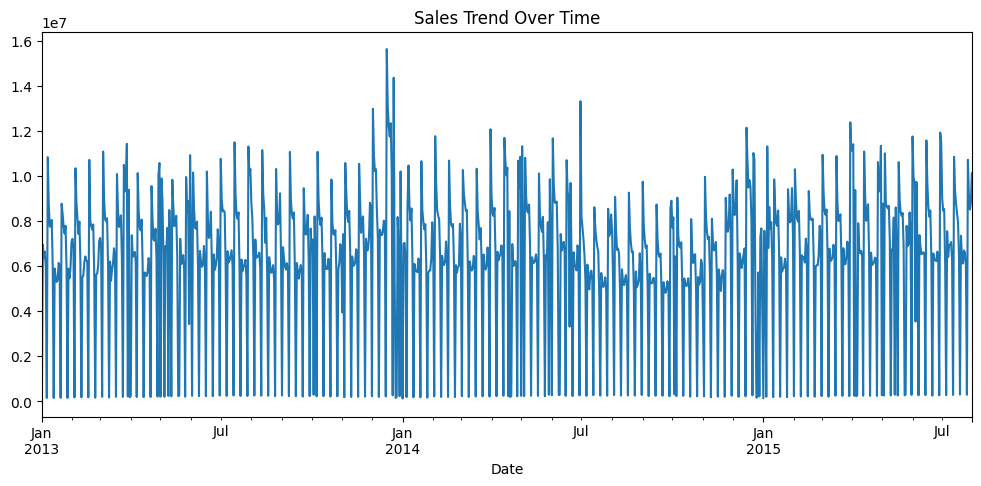

In [ ]:
daily_sales = merged_df.groupby("Date")["Sales"].sum()

plt.figure(figsize=(12,5))
daily_sales.plot()
plt.title("Sales Trend Over Time")
plt.show()

Monthly Seasonality


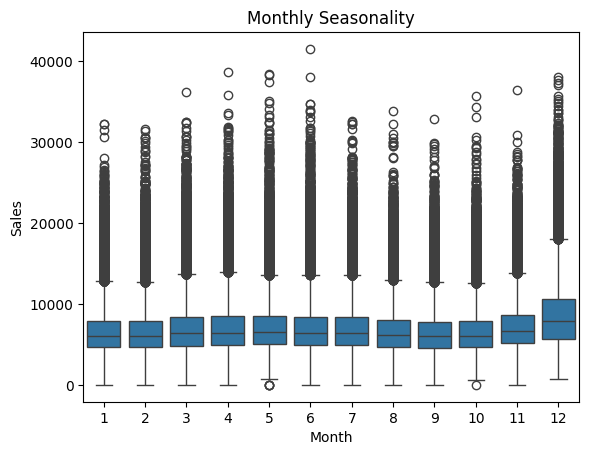

In [ ]:
sns.boxplot(x="Month", y="Sales", data=merged_df)
plt.title("Monthly Seasonality")
plt.show()

Weekly Seasonality

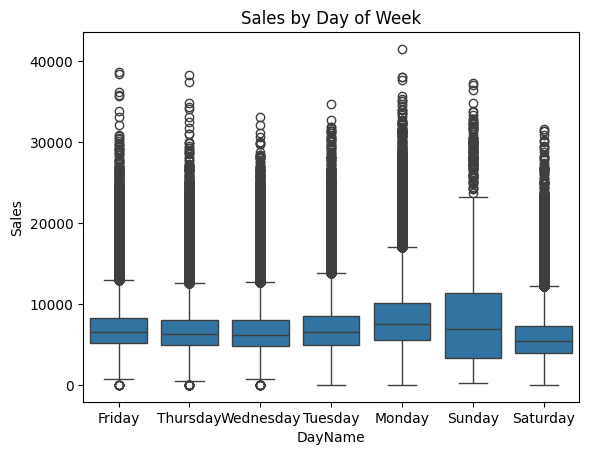

In [ ]:
sns.boxplot(x="DayName", y="Sales", data=merged_df)
plt.title("Sales by Day of Week")
plt.show()

Impact on Promo on Sales

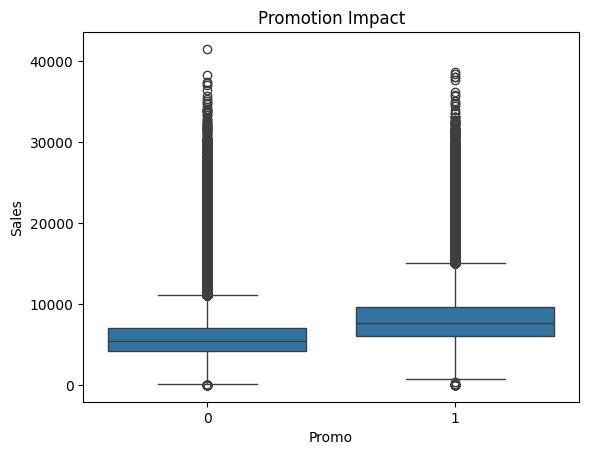

In [ ]:
sns.boxplot(x="Promo", y="Sales", data=merged_df)
plt.title("Promotion Impact")
plt.show()

Customer Analysis

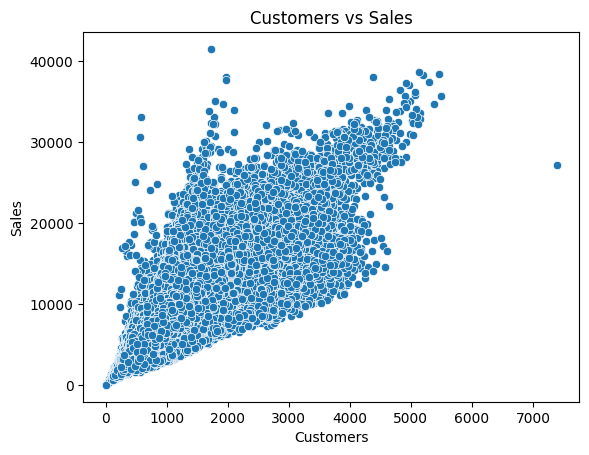

In [ ]:
sns.scatterplot(x="Customers", y="Sales", data=merged_df)
plt.title("Customers vs Sales")
plt.show()

Store type analysis

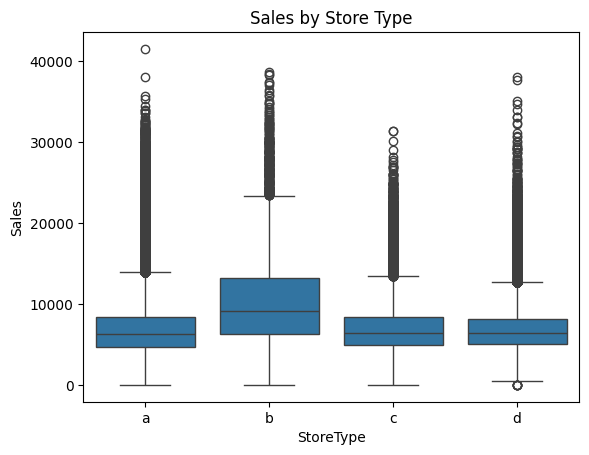

In [ ]:
sns.boxplot(x="StoreType", y="Sales", data=merged_df)
plt.title("Sales by Store Type")
plt.show()

Correlation heat-map

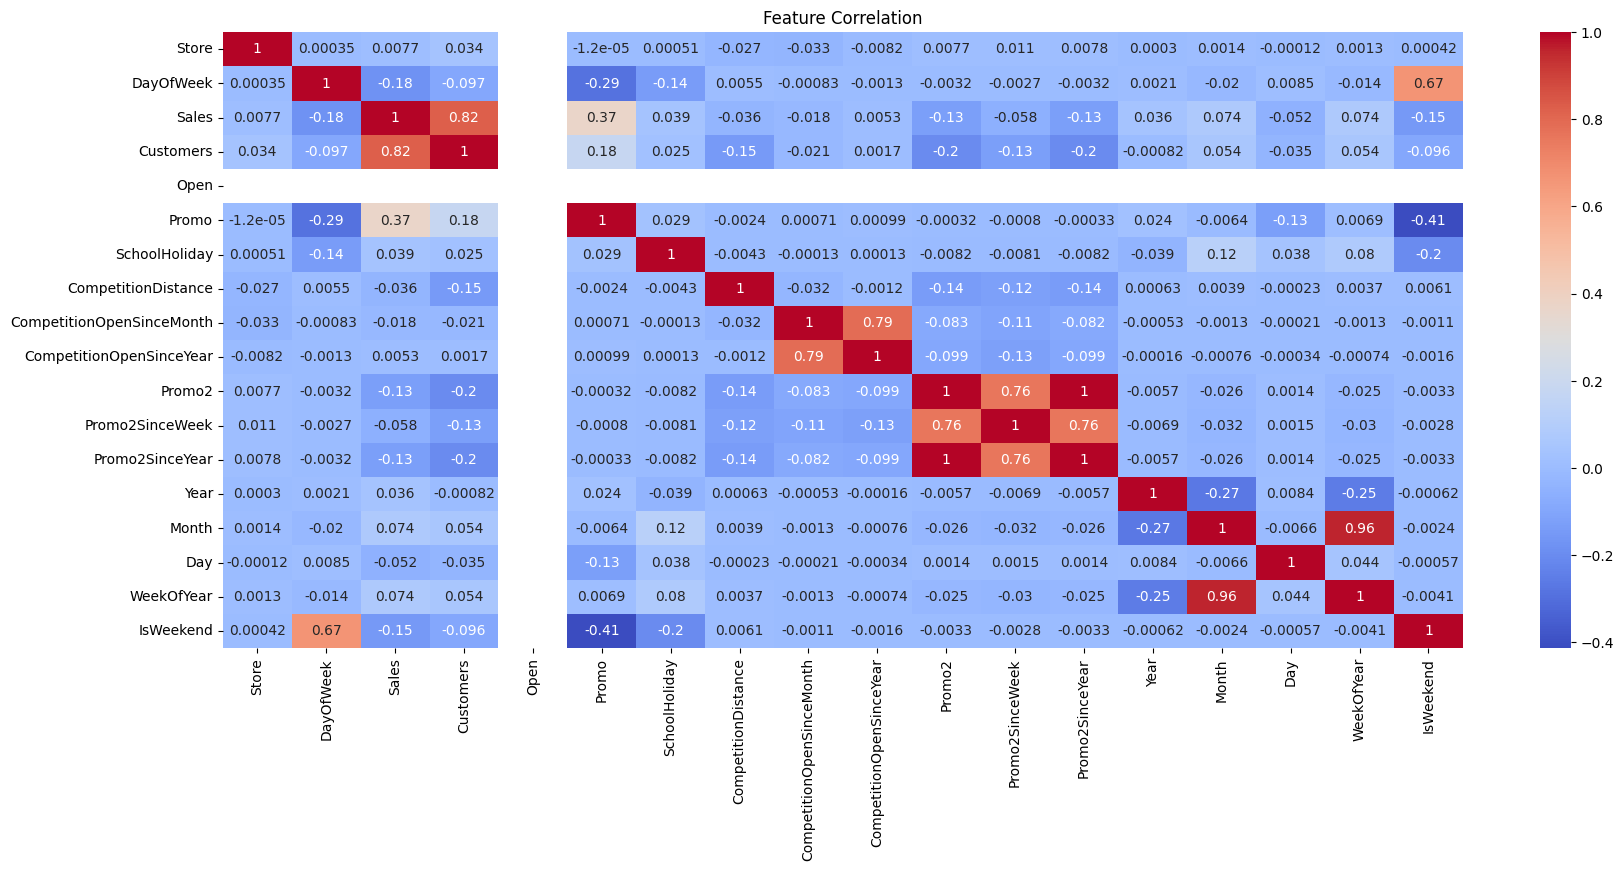

In [ ]:
corr = merged_df.corr(numeric_only=True)

plt.figure(figsize=(20,8))
sns.heatmap(corr, cmap="coolwarm",annot=True)
plt.title("Feature Correlation")
plt.show()

Evaluating using LR as baseline Model

In [ ]:
3#Log differencing
merged_df["log_sales"] = np.log1p(merged_df["Sales"])

In [ ]:
from sklearn.linear_model import LinearRegression
import pandas as pd
from sklearn.model_selection import train_test_split
# Drop 'Sales', 'log_sales', and 'Date' as they are either target or not a feature for the model
X = merged_df.drop(["Sales","log_sales","Date"], axis=1)
y = merged_df["log_sales"]

# Identify categorical columns for one-hot encoding
categorical_cols_to_encode = ["StoreType", "Assortment", "StateHoliday", "PromoInterval", "DayName"]

# Apply one-hot encoding to the categorical columns
X = pd.get_dummies(X, columns=categorical_cols_to_encode, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

y_pred = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("RMSE:", rmse)
print("R2 Score:", r2)

RMSE: 0.22213588805781978
R2 Score: 0.7358937818746732


In [ ]:
pred_sales = np.expm1(y_pred)
actual_sales = np.expm1(y_test)
rmse_sales = np.sqrt(mean_squared_error(actual_sales, pred_sales))
print(rmse_sales)

3144.4933616605717


In [ ]:
# ══════════════════════════════════════════════════════
#  MODEL 2: RANDOM FOREST
# ══════════════════════════════════════════════════════
# ══════════════════════════════════════════════════════
#  MODEL 2: RANDOM FOREST
# ══════════════════════════════════════════════════════
import time   # ← add this line
from sklearn.ensemble import RandomForestRegressor, StackingRegressor
from sklearn.linear_model import Ridge
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score

print("⏳ Training Random Forest...")
print("   (5–10 mins on Colab free CPU — don't close tab!)\n")

start = time.time()

rf = RandomForestRegressor(
    n_estimators     = 100,
    max_depth        = 12,
    min_samples_leaf = 10,
    n_jobs           = -1,
    random_state     = 42
)
rf.fit(X_train, y_train)

elapsed = (time.time() - start) / 60
print(f"✓ Done in {elapsed:.1f} mins")

rf_preds = rf.predict(X_test)
r_rf     = evaluate("Random Forest", y_test, rf_preds)

⏳ Training Random Forest...
   (5–10 mins on Colab free CPU — don't close tab!)

✓ Done in 7.3 mins

--- Random Forest Evaluation ---
Log RMSE: 0.1151
Log R2 Score: 0.9291
Actual Sales RMSE: 868.38


In [ ]:
import time   # ← add this line
from sklearn.ensemble import RandomForestRegressor, StackingRegressor
from sklearn.linear_model import Ridge
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score

def evaluate(model_name, y_true, y_pred_log):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred_log))
    r2 = r2_score(y_true, y_pred_log)

    pred_sales = np.expm1(y_pred_log)
    actual_sales = np.expm1(y_true)
    rmse_sales = np.sqrt(mean_squared_error(actual_sales, pred_sales))

    print(f"\n--- {model_name} Evaluation ---")
    print(f"Log RMSE: {rmse:.4f}")
    print(f"Log R2 Score: {r2:.4f}")
    print(f"Actual Sales RMSE: {rmse_sales:.2f}")
    return {"rmse": rmse, "r2": r2, "rmse_sales": rmse_sales}

# ══════════════════════════════════════════════════════
#  MODEL 3: XGBOOST
# ══════════════════════════════════════════════════════

print("⏳ Training XGBoost...")

start = time.time()

xgb = XGBRegressor(
    n_estimators     = 500,
    learning_rate    = 0.05,
    max_depth        = 6,
    subsample        = 0.8,
    colsample_bytree = 0.8,
    min_child_weight = 10,
    random_state     = 42,
    n_jobs           = -1,
    verbosity        = 0
)
xgb.fit(
    X_train, y_train,
    eval_set        = [(X_test, y_test)],
    verbose         = 100
)

elapsed = (time.time() - start) / 60
print(f"✓ Done in {elapsed:.1f} mins")

xgb_preds = xgb.predict(X_test)
r_xgb     = evaluate("XGBoost", y_test, xgb_preds)


⏳ Training XGBoost...
[0]	validation_0-rmse:0.42618
[100]	validation_0-rmse:0.13697
[200]	validation_0-rmse:0.11988
[300]	validation_0-rmse:0.10745
[400]	validation_0-rmse:0.09815
[499]	validation_0-rmse:0.09101
✓ Done in 1.2 mins

--- XGBoost Evaluation ---
Log RMSE: 0.0910
Log R2 Score: 0.9557
Actual Sales RMSE: 572.68


In [ ]:
# ══════════════════════════════════════════════════════
#  MODEL 4: HYBRID — FASTER VERSION FOR HACKATHON
# ══════════════════════════════════════════════════════
import time
from sklearn.utils import resample

print("⏳ Training Hybrid Stacking Model (fast version)...")

# ── Sample down to 200k rows for speed ───────────────
X_train_s, y_train_s = resample(
    X_train, y_train,
    n_samples   = 200000,
    random_state= 42
)

start = time.time()

base_models = [
    ('rf',  RandomForestRegressor(
                n_estimators     = 50,    # reduced from 100
                max_depth        = 10,    # reduced from 12
                min_samples_leaf = 20,
                n_jobs           = -1,
                random_state     = 42)),
    ('xgb', XGBRegressor(
                n_estimators     = 200,   # reduced from 300
                learning_rate    = 0.05,
                max_depth        = 5,     # reduced from 6
                subsample        = 0.8,
                colsample_bytree = 0.8,
                random_state     = 42,
                n_jobs           = -1,
                verbosity        = 0))
]

hybrid = StackingRegressor(
    estimators      = base_models,
    final_estimator = Ridge(alpha=1.0),
    cv              = 2,              # reduced from 3
    n_jobs          = -1
)

hybrid.fit(X_train_s, y_train_s)

elapsed = (time.time() - start) / 60
print(f"✓ Done in {elapsed:.1f} mins")

hybrid_preds = hybrid.predict(X_test)
r_hybrid     = evaluate("Hybrid (RF + XGBoost + Ridge)", y_test, hybrid_preds)

⏳ Training Hybrid Stacking Model (fast version)...
✓ Done in 1.7 mins

--- Hybrid (RF + XGBoost + Ridge) Evaluation ---
Log RMSE: 0.1330
Log R2 Score: 0.9054
Actual Sales RMSE: 875.31


Top 10 most influential features:
           Feature  Coefficient  Abs_Coef
PromoInterval_None    -5.793154  5.793154
            Promo2     5.793154  5.793154
       StoreType_b    -0.489856  0.489856
      Assortment_b    -0.386433  0.386433
    StateHoliday_c     0.359591  0.359591
    StateHoliday_b    -0.208275  0.208275
             Promo     0.202725  0.202725
       StoreType_d     0.173185  0.173185
    StateHoliday_a    -0.081646  0.081646
    DayName_Sunday    -0.068899  0.068899

Bottom 10 least influential (near-zero = useless):
                  Feature   Coefficient     Abs_Coef
                    Month  3.857200e-03 3.857200e-03
          Promo2SinceWeek  1.664453e-03 1.664453e-03
                Customers  9.207803e-04 9.207803e-04
CompetitionOpenSinceMonth -5.265865e-04 5.265865e-04
               WeekOfYear  2.768473e-04 2.768473e-04
                    Store -2.255769e-05 2.255769e-05
                      Day  9.726938e-06 9.726938e-06
 CompetitionOpenSinceYear  5

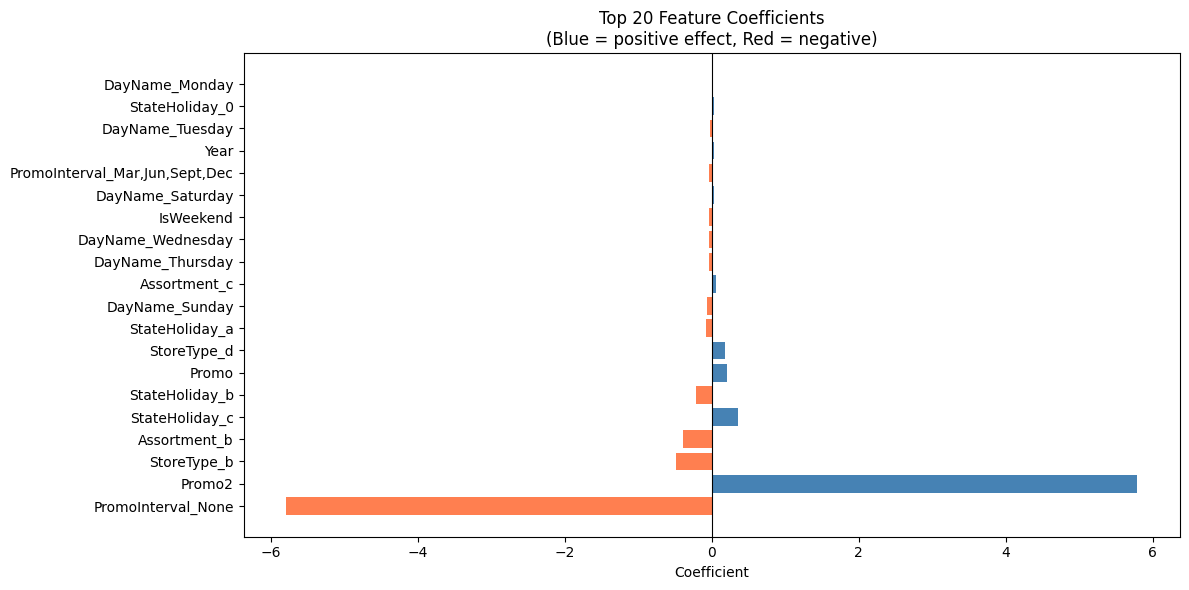

In [ ]:
# ══════════════════════════════════════════════════════
#  STEP 2 — CHECK WHICH FEATURES ARE HURTING THE MODEL
# ══════════════════════════════════════════════════════

coef_df = pd.DataFrame({
    'Feature'    : X_train.columns,
    'Coefficient': model.coef_,
    'Abs_Coef'   : np.abs(model.coef_)
}).sort_values('Abs_Coef', ascending=False)

print("Top 10 most influential features:")
print(coef_df.head(10).to_string(index=False))

print("\nBottom 10 least influential (near-zero = useless):")
print(coef_df.tail(10).to_string(index=False))

# Plot coefficients
plt.figure(figsize=(12, 6))
top20 = coef_df.head(20)
colors = ['steelblue' if c > 0 else 'coral' for c in top20['Coefficient']]
plt.barh(top20['Feature'], top20['Coefficient'], color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Top 20 Feature Coefficients\n(Blue = positive effect, Red = negative)')
plt.xlabel('Coefficient')
plt.tight_layout()
plt.show()

In [ ]:
# ══════════════════════════════════════════════════════
#  STEP 3 — ROOT CAUSE SUMMARY
# ══════════════════════════════════════════════════════

actual_sales = np.expm1(y_test)
pred_sales   = np.expm1(y_pred)
pred_sales   = np.maximum(pred_sales, 0)

rmse_log    = np.sqrt(mean_squared_error(y_test, y_pred))
r2_log      = r2_score(y_test, y_pred)
rmse_actual = np.sqrt(mean_squared_error(actual_sales, pred_sales))
r2_actual   = r2_score(actual_sales, pred_sales)

print("="*50)
print("  ROOT CAUSE ANALYSIS")
print("="*50)
print(f"\n  R² on log scale    : {r2_log:.4f}   ← looks OK")
print(f"  R² on actual sales : {r2_actual:.4f}   ← drops here")
print(f"\n  Why the drop?")
print(f"  expm1() amplifies small log errors into huge")
print(f"  actual-sales errors. LR's residuals are not")
print(f"  uniformly small — it misses peak sales days")
print(f"  badly (holidays, promotions, Sundays).")
print(f"\n  Core reasons LR underperforms:")
print(f"  1. Sales is NON-LINEAR — LR can only fit lines")
print(f"  2. Promo × DayOfWeek INTERACTION not captured")
print(f"  3. Store-specific patterns ignored")
print(f"  4. Seasonal spikes (Dec) need tree models")
print("="*50)

  ROOT CAUSE ANALYSIS

  R² on log scale    : 0.7359   ← looks OK
  R² on actual sales : -0.0253   ← drops here

  Why the drop?
  expm1() amplifies small log errors into huge
  actual-sales errors. LR's residuals are not
  uniformly small — it misses peak sales days
  badly (holidays, promotions, Sundays).

  Core reasons LR underperforms:
  1. Sales is NON-LINEAR — LR can only fit lines
  2. Promo × DayOfWeek INTERACTION not captured
  3. Store-specific patterns ignored
  4. Seasonal spikes (Dec) need tree models


In [ ]:
# ══════════════════════════════════════════════════════
#  STEP 5 — FASTER RIDGE + LASSO TUNING
#  Uses RidgeCV (built-in, 10x faster than cross_val_score)
# ══════════════════════════════════════════════════════

from sklearn.linear_model import RidgeCV, LassoCV

# ── Ridge — tests all alphas internally, very fast ───
print("⏳ Tuning Ridge...")
ridge_cv = RidgeCV(
    alphas   = [0.01, 0.1, 1, 10, 50, 100, 500],
    cv       = 3
)
ridge_cv.fit(X_train, y_train)
print(f"✓ Best Ridge alpha : {ridge_cv.alpha_}")
print(f"✓ Ridge R²         : {ridge_cv.score(X_test, y_test):.4f}")

# ── Lasso — faster with LassoCV ───────────────────────
print("\n⏳ Tuning Lasso (1–2 mins)...")
lasso_cv = LassoCV(
    alphas    = [0.0001, 0.001, 0.01, 0.05, 0.1],
    cv        = 3,
    max_iter  = 3000,
    n_jobs    = -1       # use all CPU cores
)
lasso_cv.fit(X_train, y_train)
print(f"✓ Best Lasso alpha : {lasso_cv.alpha_}")
print(f"✓ Lasso R²         : {lasso_cv.score(X_test, y_test):.4f}")

# ── Compare all 3 ─────────────────────────────────────
ridge_preds = ridge_cv.predict(X_test)
lasso_preds = lasso_cv.predict(X_test)

def eval_linear(name, preds):
    actual = np.expm1(y_test.values)
    pred   = np.maximum(np.expm1(preds), 0)
    rmse   = np.sqrt(mean_squared_error(actual, pred))
    r2     = r2_score(actual, pred)
    return {'Model': name, 'RMSE': round(rmse,2), 'R²': round(r2,4)}

lr_results = pd.DataFrame([
    eval_linear("Linear Regression", y_pred),
    eval_linear("Ridge (tuned)",     ridge_preds),
    eval_linear("Lasso (tuned)",     lasso_preds),
])

print("\n")
print("╔══════════════════════════════════════════════════╗")
print("║       LINEAR MODEL TUNING RESULTS               ║")
print("╠══════════════════════════════════════════════════╣")
print(lr_results.to_string(index=False))
print("╚══════════════════════════════════════════════════╝")
print("\n→ Done! Now move to Random Forest + XGBoost")

⏳ Tuning Ridge...
✓ Best Ridge alpha : 0.01
✓ Ridge R²         : 0.7359

⏳ Tuning Lasso (1–2 mins)...
✓ Best Lasso alpha : 0.0001
✓ Lasso R²         : 0.7356


╔══════════════════════════════════════════════════╗
║       LINEAR MODEL TUNING RESULTS               ║
╠══════════════════════════════════════════════════╣
            Model    RMSE      R²
Linear Regression 3144.49 -0.0253
    Ridge (tuned) 3144.39 -0.0252
    Lasso (tuned) 3158.23 -0.0343
╚══════════════════════════════════════════════════╝

→ Done! Now move to Random Forest + XGBoost


In [ ]:
# ══════════════════════════════════════════════════════
#  HYPERPARAMETER TUNING — LINEAR REGRESSION
#  Tune everything AROUND it to improve performance
# ══════════════════════════════════════════════════════

from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import time

X_train_c = X_train.astype(float).replace([np.inf,-np.inf],0).fillna(0)
X_test_c  = X_test.astype(float).replace([np.inf,-np.inf],0).fillna(0)
y_train_c = y_train.astype(float).fillna(0)
y_test_c  = y_test.astype(float).fillna(0)

In [ ]:
# ── Approach 1: Tune fit_intercept + positive ─────────
print("⏳ GridSearch on LinearRegression parameters...")
start = time.time()

lr_params = {
    'fit_intercept': [True, False],
    'positive'     : [True, False]
}

lr_grid = GridSearchCV(
    LinearRegression(),
    param_grid = lr_params,
    cv         = 3,
    scoring    = 'r2',
    n_jobs     = -1,
    verbose    = 1
)
lr_grid.fit(X_train_c, y_train_c)

print(f"✓ Done in {time.time()-start:.1f}s")
print(f"✓ Best params : {lr_grid.best_params_}")
print(f"✓ Best R²     : {lr_grid.best_score_:.4f}")

# Show all combinations
lr_scores = pd.DataFrame(lr_grid.cv_results_)[
    ['param_fit_intercept','param_positive','mean_test_score']
].sort_values('mean_test_score', ascending=False)
print("\nAll combinations:")
print(lr_scores.to_string(index=False))

⏳ GridSearch on LinearRegression parameters...
Fitting 3 folds for each of 4 candidates, totalling 12 fits
✓ Done in 36.7s
✓ Best params : {'fit_intercept': True, 'positive': False}
✓ Best R²     : 0.7384

All combinations:
 param_fit_intercept  param_positive  mean_test_score
                True           False         0.738439
               False           False         0.738439
                True            True         0.694699
               False            True         0.692427


In [ ]:
# ── Approach 2: Feature Selection → cleaner input ─────
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.pipeline import Pipeline

print("\n⏳ Testing SelectKBest feature selection...")
start = time.time()

pipe2 = Pipeline([
    ('selector', SelectKBest(score_func=f_regression)),
    ('scaler',   StandardScaler()),
    ('model',    LinearRegression())
])

select_params = {
    'selector__k': [5, 10, 15, 20, 'all']
}

select_grid = GridSearchCV(
    pipe2,
    param_grid = select_params,
    cv         = 3,
    scoring    = 'r2',
    n_jobs     = -1,
    verbose    = 1
)
select_grid.fit(X_train_c, y_train_c)

print(f"✓ Done in {time.time()-start:.1f}s")
print(f"✓ Best k  : {select_grid.best_params_['selector__k']}")
print(f"✓ Best R² : {select_grid.best_score_:.4f}")


⏳ Testing SelectKBest feature selection...
Fitting 3 folds for each of 5 candidates, totalling 15 fits
✓ Done in 16.2s
✓ Best k  : all
✓ Best R² : 0.7384
